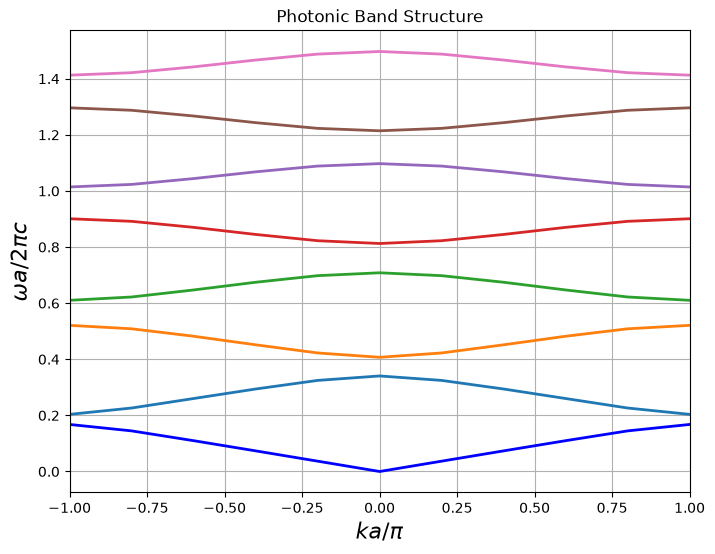

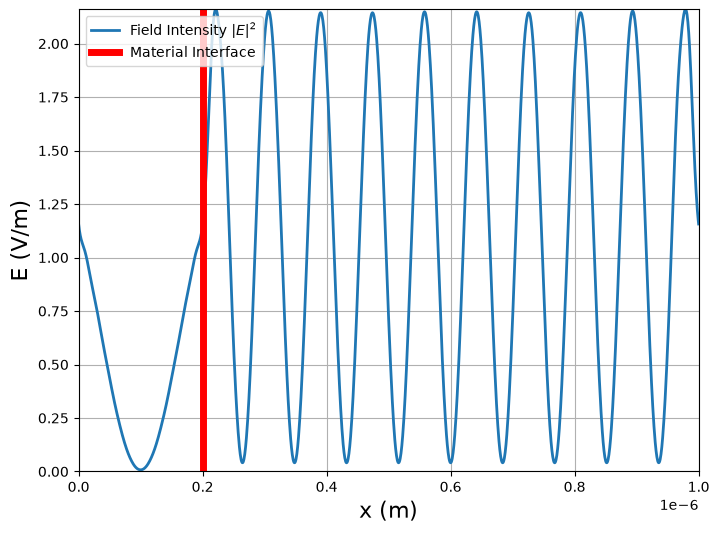

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#!conda install -y -c conda-forge libgfortran5 numpy

# Parámetros de entrada
l1 = 0.2e-6
l2 = 0.8e-6
eps1 = 1
eps2 = 9
a = l1 + l2

# Número de ondas planas
numG = 50
# Se genera el vector G que abarca de -numG a numG
G_vec = np.arange(-numG, numG + 1) * 2 * np.pi / a
N = len(G_vec) # 2 * numG + 1

# Matriz para los coeficientes de la serie de Fourier
chi = np.zeros((N, N), dtype=complex)

# Bucle para obtener los coeficientes de expansión de Fourier
for i, G in enumerate(G_vec):
    for j, G1 in enumerate(G_vec):
        # El caso (G - G1) == 0 se considera por separado
        if np.isclose(G, G1):
            chi[i, j] = 1 / (l1 + l2) * (1 / eps1 * l1 + 1 / eps2 * l2)
        else:
            term1 = 1 / eps1 * (np.exp(-1j * (G - G1) * l1) - 1)
            term2 = 1 / eps2 * (np.exp(-1j * (G - G1) * (l1 + l2)) - np.exp(-1j * (G - G1) * l1))
            chi[i, j] = 1j / (l1 + l2) / (G - G1) * (term1 + term2)

# Vector de onda k en la Zona de Brillouin
# De -pi/a a pi/a, asegurando 11 puntos (equivalente al paso 0.2 en MATLAB)
k_vec = np.linspace(-np.pi / a, np.pi / a, 11)

dispe = np.zeros((len(k_vec), N))
ks = np.zeros(len(k_vec))

# Bucle para calcular la estructura de bandas
for idx_k, k in enumerate(k_vec):
    M = np.zeros((N, N), dtype=complex)
    
    # Bucle para definir el operador diferencial matricial M
    for i, G in enumerate(G_vec):
        for j, G1 in enumerate(G_vec):
            M[i, j] = chi[i, j] * (k + G1) * (k + G)
            
    # Calculando eigenvalores de la matriz M
    eigenvalues = np.linalg.eigvals(M)
    
    # Ordenar y normalizar los autovalores obtenidos
    sorted_abs_eig = np.sort(np.abs(eigenvalues))
    dispe[idx_k, :] = np.sqrt(sorted_abs_eig) * a / (2 * np.pi)
    ks[idx_k] = k * a / np.pi

# ==========================================================
# Gráfica 1: Estructura de bandas
# ==========================================================
plt.figure(1, figsize=(8, 6))
# Graficando las primeras 8 bandas
for u in range(8):
    plt.plot(ks, dispe[:, u], linewidth=2, color='blue' if u == 0 else None)

plt.xlabel(r'$ka/\pi$', fontsize=16)
plt.ylabel(r'$\omega a / 2\pi c$', fontsize=16)
plt.xlim([-1, 1])
plt.title('Photonic Band Structure')
plt.grid(True)

# ==========================================================
# Cálculo del perfil de campo para un valor específico de k
# ==========================================================
k_field = np.pi / (15 * a) # k específico para el campo
M1 = np.zeros((N, N), dtype=complex)

for i, G in enumerate(G_vec):
    for j, G1 in enumerate(G_vec):
        M1[i, j] = chi[i, j] * (k_field + G1) * (k_field + G)

# Calculando autovalores y autovectores de M1
eigenvalues1, eigenvectors1 = np.linalg.eig(M1)

# Ordenar autovalores
idx_sort = np.argsort(np.abs(eigenvalues1))
Ds = eigenvalues1[idx_sort]
Vs = eigenvectors1[:, idx_sort]

# Seleccionamos la banda (en MATLAB in1=20, en Python es 19 por base 0)
in1 = 10 
freq = np.sqrt(np.abs(Ds[in1])) * a / (2 * np.pi)

# Definiendo el vector de espacio para graficar
div1 = 1500
x = np.linspace(0, a, div1 + 1)

# Función para calcular la dependencia del campo respecto a x
def get_field(x_vals):
    H = np.zeros_like(x_vals, dtype=complex)
    for countt, G in enumerate(G_vec):
        H += Vs[countt, in1] * np.exp(1j * (k_field + G) * x_vals)
    return H

# Evaluamos el campo y sacamos su norma al cuadrado (E*E^*)
Field = get_field(x)
FieldE = np.abs(Field)**2 

# ==========================================================
# Gráfica 2: Perfil del Campo Eléctrico
# ==========================================================
plt.figure(2, figsize=(8, 6))
alt = np.max(FieldE)

# Línea divisoria de los materiales (interfaz)
div = 15
x1 = np.linspace(0, alt, div + 1)
y1 = l1 * np.ones_like(x1)

# Graficamos el campo y la interfaz
plt.plot(x, FieldE, linewidth=2, label='Field Intensity $|E|^2$')
plt.plot(y1, x1, linewidth=5, label='Material Interface', color='red')

plt.xlabel('x (m)', fontsize=16)
plt.ylabel('E (V/m)', fontsize=16)
plt.ylim([0, alt])
plt.xlim([0, a])
plt.legend()
plt.grid(True)

# Mostrar ambas gráficas
plt.show()

In [3]:
!conda install -y -c conda-forge libgfortran5 numpy

Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /opt/anaconda3

  added / updated specs:
    - libgfortran5
    - numpy


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.7.22  |       hbd8a1cb_0         129 KB  conda-forge
    certifi-2026.7.22          |     pyhd8ed1ab_0         134 KB  conda-forge
    libgfortran-5.0.0          |14_2_0_h6c33f7e_103         153 KB  conda-forge
    libgfortran5-14.2.0        |     h6c33f7e_103         788 KB  conda-forge
    openssl-3.6.4              |       h55eecbc_0         3.0 MB  conda-forge
    ------------------------------------------------------------
                                           Total:         4.1 MB

The following packages will be UPDATED:

  ca-certificates    pkgs/main/osx-arm64::ca-certificates-~ --> c